# 论文复现：Conformalized Survival Analysis
Candès, Lei & Ren (2023), *JRSSB*, 85(1): 24–45

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import importlib
import sys, os

warnings.filterwarnings('ignore')
np.random.seed(2026)
sys.path.insert(0, os.path.abspath('.'))

import config
import config.models
import config.csa_base
import config.csa_traditional
import config.evaluation
import 复现

importlib.reload(config.models)
importlib.reload(config.csa_base)
importlib.reload(config.csa_traditional)
importlib.reload(config.evaluation)
importlib.reload(复现)

from config.models import fit_cox, predict_mean_survival_truncated
from config.csa_base import estimate_c0_on_train, estimate_censoring_weights, calibrate_csa_quantile
from config.csa_traditional import fit_csa_intervals_traditional
from 复现 import (
    generate_paper_lognormal_data,
    compute_cdr_nonconformity_scores, compute_cdr_lower_bound,
    naive_split_conformal_lpb, direct_model_lpb,
    csa_cdr_lpb, run_single_trial,
)

plt.rcParams['font.family'] = ['Heiti TC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

print('✅ 所有模块加载成功')

✅ 所有模块加载成功


## Table 1：四种数据生成设定

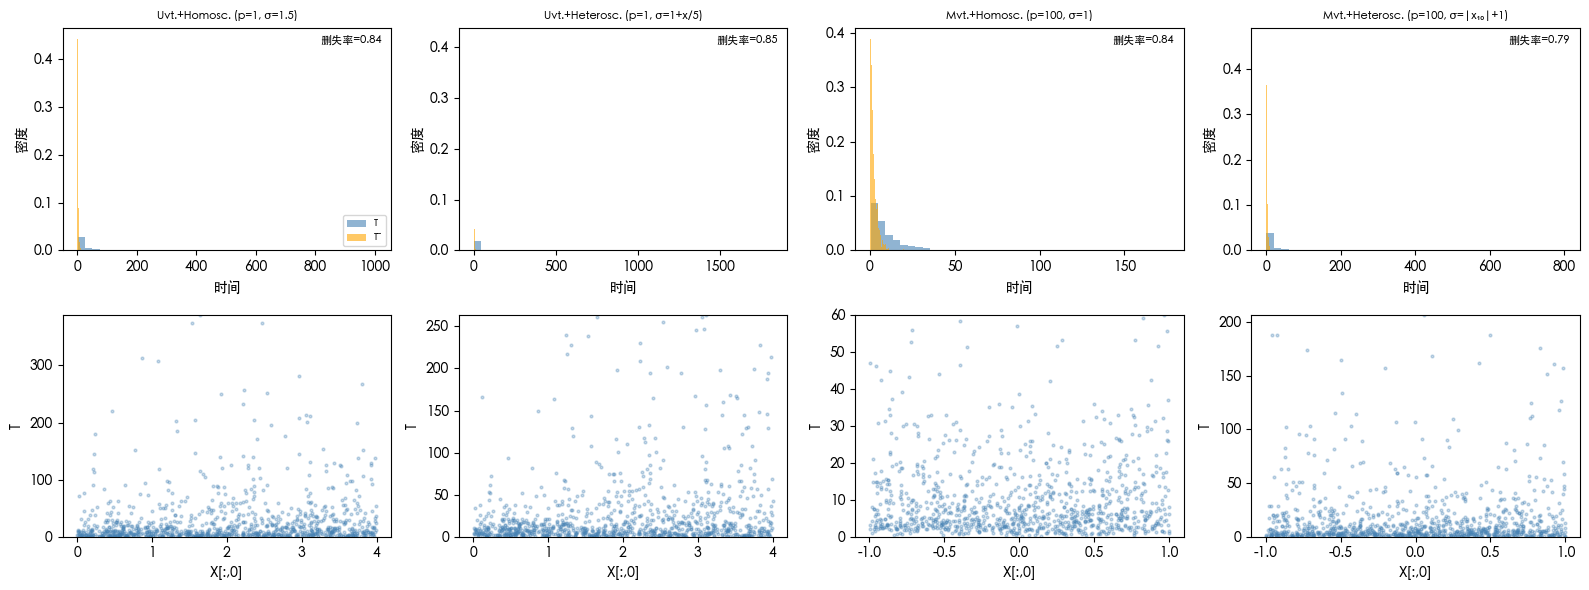

In [7]:
SCENARIOS = ['uvt_homo', 'uvt_hetero', 'mvt_homo', 'mvt_hetero']
LABELS = {
    'uvt_homo':   'Uvt.+Homosc. (p=1, σ=1.5)',
    'uvt_hetero': 'Uvt.+Heterosc. (p=1, σ=1+x/5)',
    'mvt_homo':   'Mvt.+Homosc. (p=100, σ=1)',
    'mvt_hetero': 'Mvt.+Heterosc. (p=100, σ=|x₁₀|+1)',
}

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for col, sc in enumerate(SCENARIOS):
    X, t_obs, ev, T, C = generate_paper_lognormal_data(1000, sc, seed=42)
    axes[0, col].hist(T, bins=40, alpha=0.6, color='steelblue', density=True, label='T')
    axes[0, col].hist(t_obs, bins=40, alpha=0.6, color='orange', density=True, label='T̃')
    axes[0, col].set_title(LABELS[sc], fontsize=8)
    axes[0, col].set_xlabel('时间'); axes[0, col].set_ylabel('密度')
    if col == 0: axes[0, col].legend(fontsize=7)
    axes[0, col].text(0.97, 0.97, f'删失率={1-ev.mean():.2f}',
                      transform=axes[0, col].transAxes, va='top', ha='right', fontsize=8)
    axes[1, col].scatter(X[:, 0], T, alpha=0.3, s=4, c='steelblue')
    axes[1, col].set_xlabel('X[:,0]'); axes[1, col].set_ylabel('T')
    axes[1, col].set_ylim(0, np.percentile(T, 99))
plt.tight_layout()
plt.show()

## Algorithm 1 逐步演示（uvt_homo, n=600, α=0.1）

In [8]:
ALPHA = 0.1

# 数据生成与划分
X_all, t_obs, ev, T, C = generate_paper_lognormal_data(600, 'uvt_homo', seed=0)
np.random.seed(2026)
idx = np.random.permutation(600)
n_fit, n_cal = 300, 150
X_fit,  t_fit,  ev_fit,  C_fit  = X_all[idx[:n_fit]],  t_obs[idx[:n_fit]],  ev[idx[:n_fit]],  C[idx[:n_fit]]
X_cal,  t_cal,  ev_cal,  C_cal  = X_all[idx[n_fit:n_fit+n_cal]], t_obs[idx[n_fit:n_fit+n_cal]], ev[idx[n_fit:n_fit+n_cal]], C[idx[n_fit:n_fit+n_cal]]
X_test, t_test, ev_test, T_test = X_all[idx[n_fit+n_cal:]], t_obs[idx[n_fit+n_cal:]], ev[idx[n_fit+n_cal:]], T[idx[n_fit+n_cal:]]

# Step 1: 拟合模型
model = fit_cox(X_fit, t_fit, ev_fit)

# Step 2: c₀ 选择 + 筛选 I'_ca = {i: C_i ≥ c₀}
c0, _ = estimate_c0_on_train(X_fit, t_fit, ev_fit, model, model_type='cox',
                              cens_time_train=C_fit, verbose=False)
cal_mask = C_cal >= c0
X_cp, t_cp = X_cal[cal_mask], t_cal[cal_mask]
print(f"c₀={c0:.4f}  |I'_ca|={cal_mask.sum()}/{len(t_cal)}")

# Step 3: 非一致性分数
scores_cmr = predict_mean_survival_truncated(model, X_cp, c0, 'cox') - np.minimum(t_cp, c0)
scores_cdr = compute_cdr_nonconformity_scores(model, X_cp, t_cp, c0, ALPHA, 'cox')

# Step 4: 权重 W_i = P(C≥c₀) / P(C≥c₀|X_i)
p_c0 = float(np.mean(C_fit >= c0))
weights, _, censor_model = estimate_censoring_weights(
    X_fit, t_fit, ev_fit, X_cp, c0_threshold=c0,
    p_c0_marginal=p_c0, cens_time_train=C_fit, verbose=False)

# Step 5-6: 测试点权重 + 加权分位数 η(x)
_tp = censor_model.predict_proba(X_test)
w_test = p_c0 / np.clip(_tp[:, 1] if _tp.shape[1] > 1 else np.full(len(X_test), float(censor_model.classes_[0])), 0.01, 0.99)
eta_cmr = calibrate_csa_quantile(scores_cmr, ALPHA, weights=weights, test_weight=w_test)
eta_cdr = calibrate_csa_quantile(scores_cdr, ALPHA, weights=weights, test_weight=w_test)

# Output: L̂(x)
m_hat = predict_mean_survival_truncated(model, X_test, c0, 'cox')
lpb_cmr = np.clip(m_hat - np.where(np.isfinite(eta_cmr), eta_cmr, m_hat), 0, c0)
lpb_cdr = compute_cdr_lower_bound(model, X_test, eta_cdr, c0, ALPHA, 'cox')
lpb_naive  = naive_split_conformal_lpb(model, X_cal, t_cal, X_test, ALPHA, 'cox')
lpb_direct = direct_model_lpb(model, X_test, ALPHA, 'cox')

def cov(lb): return float(np.mean(T_test >= lb))
print(f"{'方法':<18} {'覆盖率':>8} {'均值LPB':>10}")
print(f"{'直接模型':<18} {cov(lpb_direct):>8.4f} {lpb_direct.mean():>10.4f}")
print(f"{'Naive CQR':<18} {cov(lpb_naive):>8.4f} {lpb_naive.mean():>10.4f}")
print(f"{'CMR-LPB':<18} {cov(lpb_cmr):>8.4f} {lpb_cmr.mean():>10.4f}")
print(f"{'CDR-LPB':<18} {cov(lpb_cdr):>8.4f} {lpb_cdr.mean():>10.4f}")
print(f"目标覆盖率: {1-ALPHA:.2f}")

c₀=2.4664  |I'_ca|=67/150
方法                      覆盖率      均值LPB
直接模型                 0.9067     1.9333
Naive CQR            1.0000     0.1613
CMR-LPB              0.9733     0.7837
CDR-LPB              0.9800     0.7866
目标覆盖率: 0.90


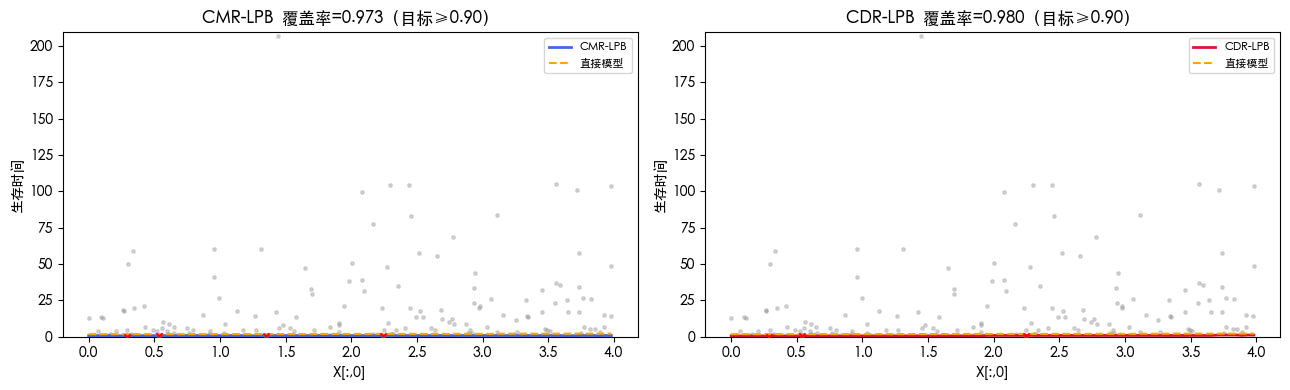

In [9]:
x_vals = X_test[:, 0]
order = np.argsort(x_vals)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (title, lpb, color) in zip(axes, [('CMR-LPB', lpb_cmr, 'royalblue'), ('CDR-LPB', lpb_cdr, 'crimson')]):
    ax.scatter(x_vals, T_test, alpha=0.3, s=6, c='gray', zorder=1)
    ax.scatter(x_vals[T_test < lpb], T_test[T_test < lpb], s=20, c='red', marker='x', zorder=3, linewidths=1.5)
    ax.plot(x_vals[order], lpb[order], color=color, lw=2, label=title, zorder=2)
    ax.plot(x_vals[order], lpb_direct[order], '--', color='orange', lw=1.5, label='直接模型', zorder=2)
    ax.set_title(f'{title}  覆盖率={cov(lpb):.3f}（目标≥0.90）')
    ax.set_xlabel('X[:,0]'); ax.set_ylabel('生存时间'); ax.legend(fontsize=8)
    ax.set_ylim(0, np.percentile(T_test, 98))
plt.tight_layout()
plt.show()

## Section 4：仿真实验

In [10]:
import time

N_REPS  = 200   # 论文: 200
N_TOTAL = 6000  # 论文: 3000 train + 3000 test
ALPHA   = 0.10
MODEL_T = 'cox'
RUN_CDR = True

LABELS = {
    'uvt_homo':   'Uvt.+Homosc.\n(p=1, σ=1.5)',
    'uvt_hetero': 'Uvt.+Heterosc.\n(p=1, σ=1+x/5)',
    'mvt_homo':   'Mvt.+Homosc.\n(p=100, σ=1)',
    'mvt_hetero': 'Mvt.+Heterosc.\n(p=100, σ=|x₁₀|+1)',
}

print(f'配置: N_REPS={N_REPS}, N_TOTAL={N_TOTAL}, α={ALPHA}, model={MODEL_T}')

配置: N_REPS=200, N_TOTAL=6000, α=0.1, model=cox


In [11]:
all_results = []

for sc in SCENARIOS:
    print(f"\n场景: {LABELS[sc].replace(chr(10), ' ')}")
    t0 = time.time()
    for trial in range(N_REPS):
        seed = trial * 997 + hash(sc) % 997
        try:
            res = run_single_trial(seed=seed, scenario=sc, alpha=ALPHA,
                                   n_total=N_TOTAL, fit_frac=0.5, test_frac=0.5,
                                   model_type=MODEL_T, run_cdr=RUN_CDR)
            all_results.append(res)
        except Exception as e:
            print(f"  Trial {trial+1} 失败: {e}")
            continue
        if (trial + 1) % 20 == 0 or trial == 0:
            eta = (time.time()-t0)/(trial+1)*(N_REPS-trial-1)
            cdr_str = f"  cdr={res.get('cdr_coverage', 0):.3f}" if RUN_CDR else ""
            print(f"  Trial {trial+1:3d}/{N_REPS}  direct={res['direct_coverage']:.3f}"
                  f"  naive={res['naive_coverage']:.3f}  cmr={res['cmr_coverage']:.3f}"
                  f"{cdr_str}  ETA={eta/60:.1f}min")

df_results = pd.DataFrame(all_results)
print(f"\n✅ 仿真完成，共 {len(df_results)} 条记录")


场景: Uvt.+Homosc. (p=1, σ=1.5)
  Trial   1/200  direct=0.899  naive=0.994  cmr=0.898  cdr=0.902  ETA=10.1min
  Trial  20/200  direct=0.903  naive=0.983  cmr=0.905  cdr=0.909  ETA=7.8min
  Trial  40/200  direct=0.874  naive=0.980  cmr=0.886  cdr=0.882  ETA=7.0min
  Trial  60/200  direct=0.903  naive=0.982  cmr=0.867  cdr=0.858  ETA=6.1min
  Trial  80/200  direct=0.904  naive=0.988  cmr=0.929  cdr=0.938  ETA=5.2min
  Trial 100/200  direct=0.895  naive=0.993  cmr=0.849  cdr=0.849  ETA=4.4min
  Trial 120/200  direct=0.885  naive=0.990  cmr=0.918  cdr=0.919  ETA=3.5min
  Trial 140/200  direct=0.907  naive=0.992  cmr=0.927  cdr=0.928  ETA=2.6min
  Trial 160/200  direct=0.912  naive=0.994  cmr=0.904  cdr=0.913  ETA=1.8min
  Trial 180/200  direct=0.894  naive=0.993  cmr=0.910  cdr=0.920  ETA=0.9min
  Trial 200/200  direct=0.893  naive=0.992  cmr=0.894  cdr=0.917  ETA=0.0min

场景: Uvt.+Heterosc. (p=1, σ=1+x/5)
  Trial   1/200  direct=0.883  naive=0.997  cmr=0.930  cdr=0.931  ETA=9.4min
  Trial  

## Figure 1

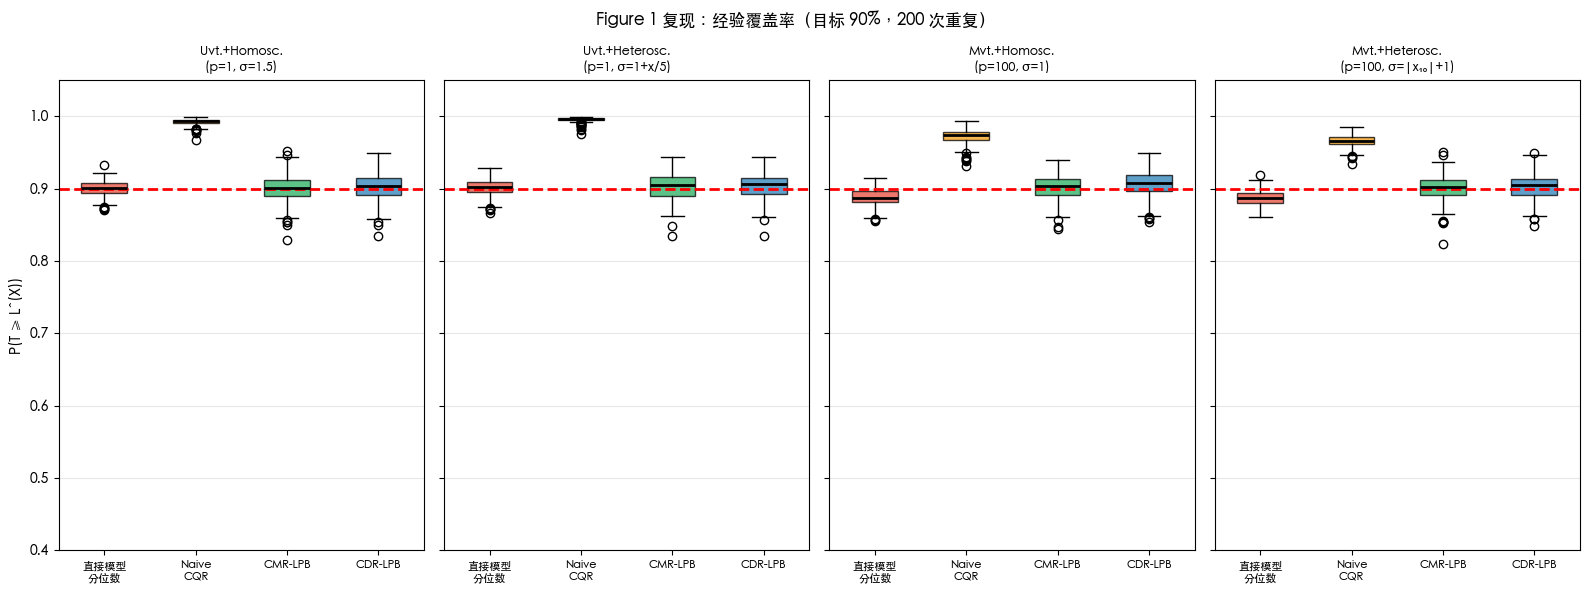

✅ 保存为 Figure1_复现.png


In [12]:
METHOD_COLS = {
    'direct': ('直接模型\n分位数', '#e74c3c'),
    'naive':  ('Naive\nCQR',       '#f39c12'),
    'cmr':    ('CMR-LPB',          '#27ae60'),
}
if RUN_CDR:
    METHOD_COLS['cdr'] = ('CDR-LPB', '#2980b9')

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
fig.suptitle(f'Figure 1 复现：经验覆盖率（目标 90%，{N_REPS} 次重复）', fontsize=12, fontweight='bold')
for col, sc in enumerate(SCENARIOS):
    ax = axes[col]
    sc_df = df_results[df_results['scenario'] == sc]
    data = [sc_df[f'{k}_coverage'].dropna().values for k in METHOD_COLS]
    colors = [v[1] for v in METHOD_COLS.values()]
    labels = [v[0] for v in METHOD_COLS.values()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.axhline(1 - ALPHA, color='red', lw=2, ls='--')
    ax.set_xticks(range(1, len(labels)+1)); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(LABELS[sc], fontsize=9, fontweight='bold')
    ax.set_ylim(0.4, 1.05)
    if col == 0: ax.set_ylabel('P(T ≥ L̂(X))', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure1_复现.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 保存为 Figure1_复现.png')

## 覆盖率汇总

In [13]:
rows = []
for sc in SCENARIOS:
    sc_df = df_results[df_results['scenario'] == sc]
    row = {'场景': LABELS[sc].replace('\n', ' ')}
    for k, (label, _) in METHOD_COLS.items():
        vals = sc_df[f'{k}_coverage'].dropna().values
        row[label.replace('\n', ' ')] = f'{vals.mean():.3f} ± {vals.std():.3f}'
    rows.append(row)
pd.DataFrame(rows).set_index('场景')

,直接模型 分位数,Naive CQR,CMR-LPB,CDR-LPB
场景,,,,
"Uvt.+Homosc. (p=1, σ=1.5)",0.900 ± 0.010,0.992 ± 0.004,0.901 ± 0.019,0.902 ± 0.020
"Uvt.+Heterosc. (p=1, σ=1+x/5)",0.901 ± 0.011,0.995 ± 0.003,0.903 ± 0.019,0.903 ± 0.019
"Mvt.+Homosc. (p=100, σ=1)",0.888 ± 0.011,0.972 ± 0.011,0.902 ± 0.017,0.907 ± 0.019
"Mvt.+Heterosc. (p=100, σ=|x₁₀|+1)",0.887 ± 0.010,0.966 ± 0.008,0.901 ± 0.018,0.904 ± 0.018


## Figure 2：条件覆盖率与效率分析

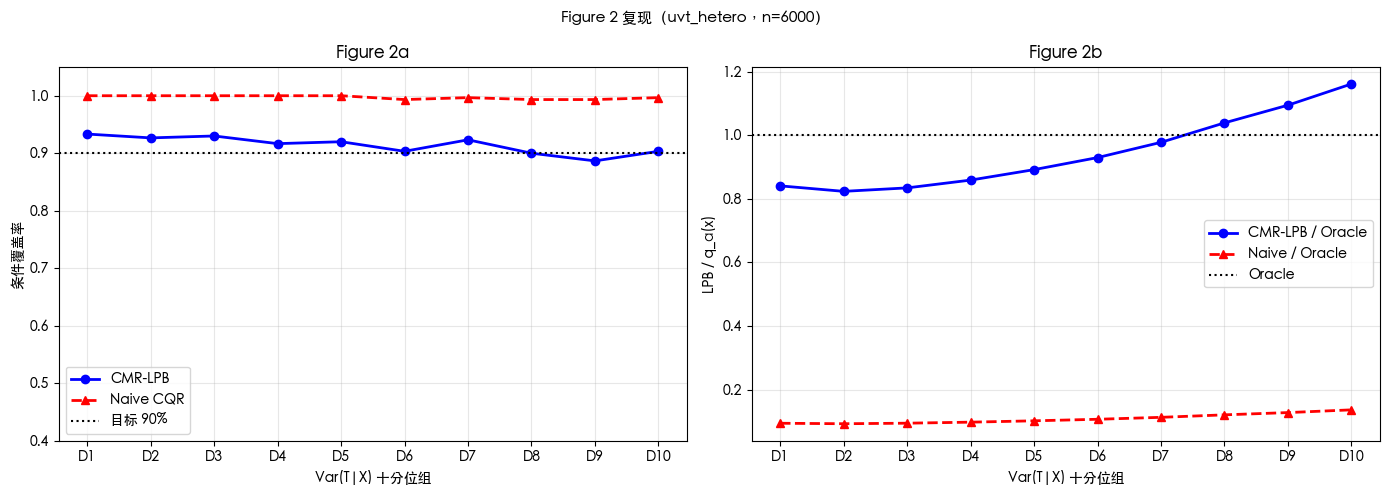

✅ 保存为 Figure2_复现.png


In [14]:
from scipy.stats import norm as sp_norm

def oracle_var_T(X, scenario):
    if scenario in ('uvt_homo', 'uvt_hetero'):
        x = X[:,0]; mu = 2.0 + 0.37*np.sqrt(x)
        sg = 1.5*np.ones(len(x)) if scenario == 'uvt_homo' else 1.0 + x/5
    else:
        mu = np.log(2)+1+0.55*(X[:,0]**2 - X[:,2]*X[:,4])
        sg = np.ones(len(X)) if scenario == 'mvt_homo' else np.abs(X[:,9])+1
    return (np.exp(sg**2)-1)*np.exp(2*mu+sg**2)

def oracle_quantile(X, scenario, alpha):
    z = sp_norm.ppf(alpha)
    if scenario in ('uvt_homo', 'uvt_hetero'):
        x = X[:,0]; mu = 2.0+0.37*np.sqrt(x)
        sg = 1.5*np.ones(len(x)) if scenario == 'uvt_homo' else 1.0+x/5
    else:
        mu = np.log(2)+1+0.55*(X[:,0]**2-X[:,2]*X[:,4])
        sg = np.ones(len(X)) if scenario == 'mvt_homo' else np.abs(X[:,9])+1
    return np.exp(mu + sg*z)

# 单次大样本（uvt_hetero，异方差最明显）
sc = 'uvt_hetero'
np.random.seed(9999)
X_big, t_big, ev_big, T_big, C_big = generate_paper_lognormal_data(6000, sc, seed=9999)
idx_b = np.random.permutation(6000)
n_f = n_c = 1500
i_fit, i_cal, i_te = idx_b[:n_f], idx_b[n_f:n_f+n_c], idx_b[n_f+n_c:]

model_b = fit_cox(X_big[i_fit], t_big[i_fit], ev_big[i_fit])
lpb_cmr_b, _, _, _ = fit_csa_intervals_traditional(
    model_b, X_big[i_fit], t_big[i_fit], ev_big[i_fit],
    X_big[i_cal], t_big[i_cal], ev_big[i_cal], X_big[i_te],
    alpha=ALPHA, model_type='cox', use_weights=True,
    cens_time_train=C_big[i_fit], cens_time_cal=C_big[i_cal], verbose=False)
lpb_naive_b = naive_split_conformal_lpb(model_b, X_big[i_cal], t_big[i_cal], X_big[i_te], ALPHA, 'cox')

cov_cmr   = (T_big[i_te] >= lpb_cmr_b).astype(float)
cov_naive = (T_big[i_te] >= lpb_naive_b).astype(float)
var_te    = oracle_var_T(X_big[i_te], sc)
q_oracle  = oracle_quantile(X_big[i_te], sc, ALPHA)

bins = np.percentile(var_te, np.linspace(0, 100, 11))
dec = np.zeros(len(i_te), dtype=int)
for k in range(10):
    dec[(var_te >= bins[k]) & (var_te <= bins[k+1])] = k
x_d = np.arange(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Figure 2 复现（{sc}，n=6000）', fontsize=11, fontweight='bold')

# Figure 2a: 条件覆盖率
axes[0].plot(x_d, [cov_cmr[dec==k].mean()   for k in range(10)], 'b-o', lw=2, label='CMR-LPB')
axes[0].plot(x_d, [cov_naive[dec==k].mean() for k in range(10)], 'r--^', lw=2, label='Naive CQR')
axes[0].axhline(1-ALPHA, color='black', lw=1.5, ls=':', label=f'目标 {1-ALPHA:.0%}')
axes[0].set_xticks(x_d); axes[0].set_xticklabels([f'D{k+1}' for k in range(10)])
axes[0].set_xlabel('Var(T|X) 十分位组'); axes[0].set_ylabel('条件覆盖率')
axes[0].set_title('Figure 2a'); axes[0].set_ylim(0.4, 1.05); axes[0].legend(); axes[0].grid(alpha=0.3)

# Figure 2b: 效率（LPB / oracle）
axes[1].plot(x_d, [np.median((lpb_cmr_b/q_oracle)[dec==k])   for k in range(10)], 'b-o', lw=2, label='CMR-LPB / Oracle')
axes[1].plot(x_d, [np.median((lpb_naive_b/q_oracle)[dec==k]) for k in range(10)], 'r--^', lw=2, label='Naive / Oracle')
axes[1].axhline(1.0, color='black', lw=1.5, ls=':', label='Oracle')
axes[1].set_xticks(x_d); axes[1].set_xticklabels([f'D{k+1}' for k in range(10)])
axes[1].set_xlabel('Var(T|X) 十分位组'); axes[1].set_ylabel('LPB / q_α(x)')
axes[1].set_title('Figure 2b'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Figure2_复现.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 保存为 Figure2_复现.png')